In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sqlalchemy import create_engine
 
engine = create_engine('postgresql://postgres@localhost/postgres')

os.makedirs('figures', exist_ok=True)


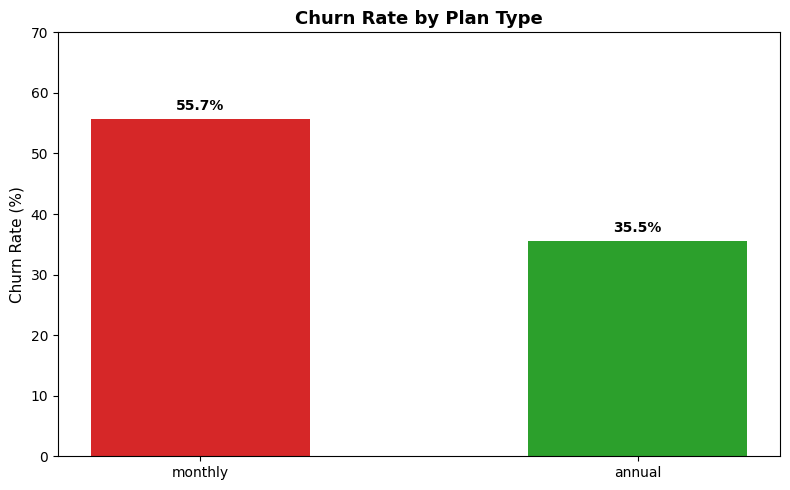

In [ ]:
# VIS 1: Churn by Plan Type

plan_churn = pd.read_sql("""
    SELECT plan,
           ROUND(100.0 * COUNT(CASE WHEN status = 'cancelled' THEN 1 END) / 
                 COUNT(DISTINCT subscription_id), 2) AS churn_rate
    FROM breathwork_app_schema.mart_churn
    GROUP BY plan
    ORDER BY churn_rate DESC
""", engine)
 
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#d62728' if x > 50 else '#2ca02c' for x in plan_churn['churn_rate']]
ax.bar(plan_churn['plan'], plan_churn['churn_rate'], color=colors, width=0.5)
ax.set_ylabel('Churn Rate (%)', fontsize=11)
ax.set_ylim(0, 70)
for i, v in enumerate(plan_churn['churn_rate']):
    ax.text(i, v + 1.5, f'{v:.1f}%', ha='center', fontweight='bold')
plt.title('Churn Rate by Plan Type', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/01_churn_by_plan.png', dpi=300, bbox_inches='tight')
plt.show()


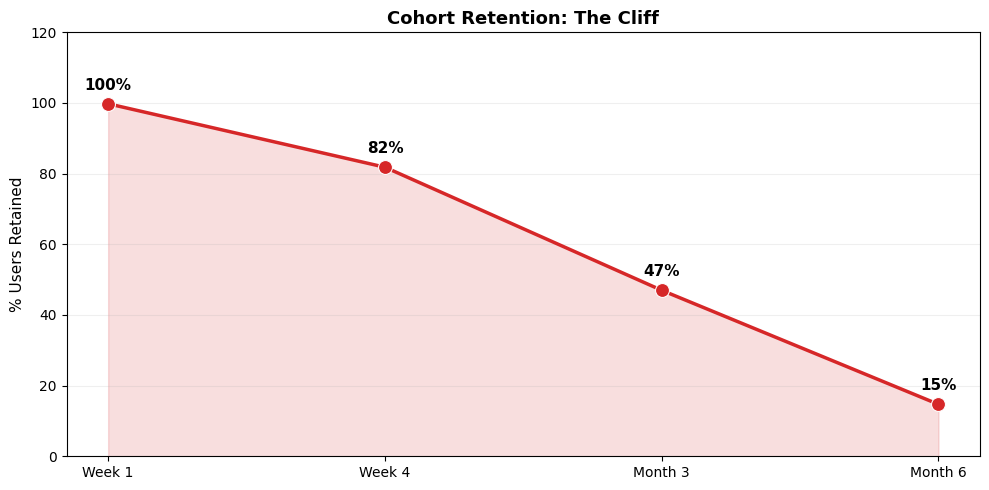

In [ ]:
# VIS 2: Cohort Retention Curve
retention = pd.read_sql("""
    WITH user_cohort AS (
        SELECT user_id, DATE_TRUNC('week', created_at) AS cohort_week
        FROM breathwork_app_schema.mart_user_activation
    ),
    user_activity AS (
        SELECT user_id, DATE_TRUNC('week', started_at) AS activity_week
        FROM breathwork_app_schema.mart_engagement
    ),
    cohort_activity AS (
        SELECT uc.user_id, uc.cohort_week, ua.activity_week,
               EXTRACT(DAY FROM (ua.activity_week - uc.cohort_week))::INT / 7 AS weeks_since_signup
        FROM user_cohort uc
        JOIN user_activity ua ON uc.user_id = ua.user_id
    )
    SELECT cohort_week,
           COUNT(DISTINCT CASE WHEN weeks_since_signup = 0 THEN user_id END) AS week0,
           COUNT(DISTINCT CASE WHEN weeks_since_signup = 1 THEN user_id END) AS week1,
           COUNT(DISTINCT CASE WHEN weeks_since_signup = 4 THEN user_id END) AS week4,
           COUNT(DISTINCT CASE WHEN weeks_since_signup = 12 THEN user_id END) AS month3,
           COUNT(DISTINCT CASE WHEN weeks_since_signup = 24 THEN user_id END) AS month6
    FROM cohort_activity
    GROUP BY cohort_week
    ORDER BY cohort_week
""", engine)
 
pct_cols = ['week1', 'week4', 'month3', 'month6']
retention[pct_cols] = (
    retention[pct_cols]
    .div(retention['week0'], axis=0)
    .mul(100)
    .round(1)
)

avg_retention = (
    retention[[f'{c}' for c in pct_cols]]
    .mean()
    .rename({'week1': 'Week 1', 'week4': 'Week 4',
             'month3': 'Month 3', 'month6': 'Month 6'})
    .reset_index()
    .rename(columns={'index': 'Milestone', 0: 'Retention (%)'})
)

fig, ax = plt.subplots(figsize=(10, 5))

sns.lineplot(
    data=avg_retention, x='Milestone', y='Retention (%)',
    marker='o', linewidth=2.5, markersize=10, color='#d62728', ax=ax
)

ax.fill_between(
    avg_retention.index, avg_retention['Retention (%)'],
    alpha=0.15, color='#d62728'
)

avg_retention.apply(
    lambda row: ax.text(
        row.name, row['Retention (%)'] + 4,
        f"{row['Retention (%)']:.0f}%",
        ha='center', fontweight='bold', fontsize=11
    ), axis=1
)

ax.set_ylim(0, 120)
ax.set_xlabel('')
ax.set_ylabel('% Users Retained', fontsize=11)
ax.grid(axis='y', alpha=0.2)

plt.title('Cohort Retention: The Cliff', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/02_retention_curve.png', dpi=300, bbox_inches='tight')
plt.show()

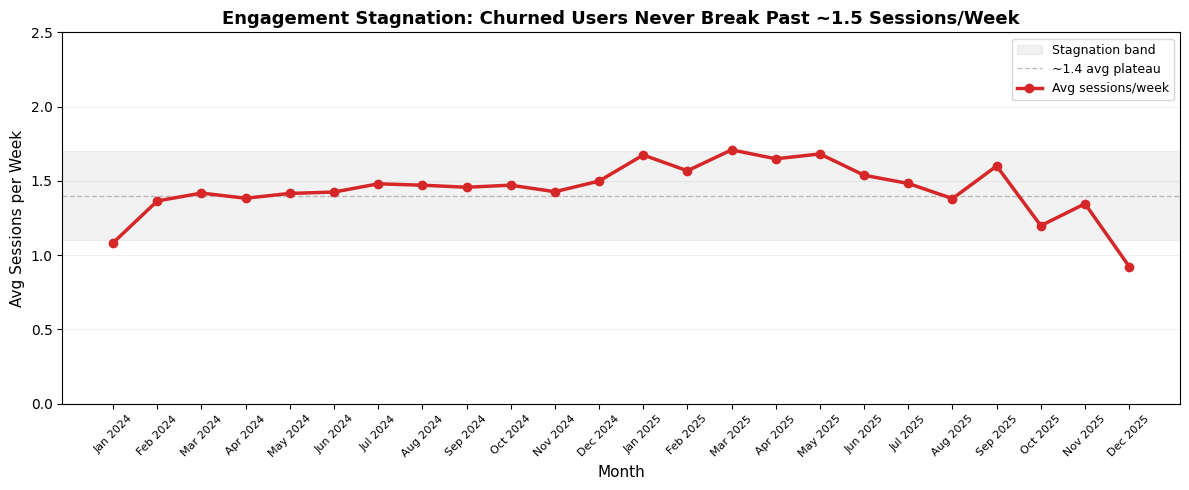

In [19]:
# VIS 3: Engagement Stagnation

engagement = pd.read_sql("""
    SELECT DATE_TRUNC('month', e.started_at) AS month,
           ROUND(COUNT(DISTINCT e.session_id)::NUMERIC / NULLIF(COUNT(DISTINCT e.user_id), 0), 2) AS sessions_per_user
    FROM breathwork_app_schema.mart_engagement e
    JOIN breathwork_app_schema.mart_churn c ON e.user_id = c.user_id
    WHERE c.status = 'cancelled'
    GROUP BY 1
    ORDER BY 1
""", engine)

engagement['sessions_per_week'] = engagement['sessions_per_user'] / 4.33

fig, ax = plt.subplots(figsize=(12, 5))

ax.axhspan(1.1, 1.7, alpha=0.10, color='gray', label='Stagnation band', zorder=1)
ax.axhline(y=1.4, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='~1.4 avg plateau', zorder=2)

ax.plot(range(len(engagement)), engagement['sessions_per_week'],
        linewidth=2.5, color='#d62728', marker='o', markersize=6,
        label='Avg sessions/week', zorder=3)

ax.set_ylabel('Avg Sessions per Week', fontsize=11)
ax.set_xlabel('Month', fontsize=11)
ax.set_xticks(range(len(engagement)))
ax.set_xticklabels(engagement['month'].dt.strftime('%b %Y'), fontsize=8, rotation=45)
ax.set_ylim(0, 2.5)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.2)

plt.title('Engagement Stagnation: Churned Users Never Break Past ~1.5 Sessions/Week',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/03_engagement_trajectory.png', dpi=300, bbox_inches='tight')
plt.show()

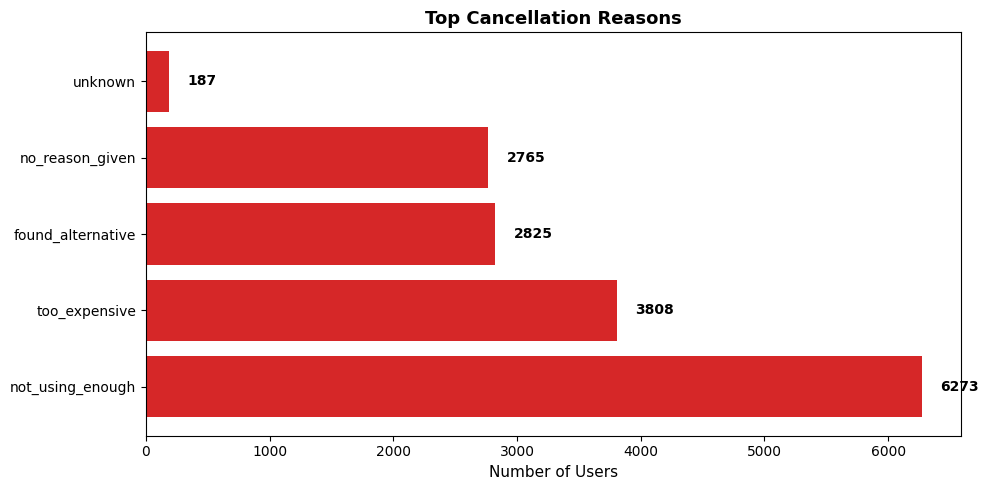

In [5]:
# VIS 4: Cancellation Reasons
reasons = pd.read_sql("""
    SELECT cancellation_reason, COUNT(*) AS count
    FROM breathwork_app_schema.mart_churn
    WHERE status = 'cancelled' AND cancellation_reason IS NOT NULL
    GROUP BY cancellation_reason
    ORDER BY count DESC
""", engine)
 
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(reasons['cancellation_reason'], reasons['count'], color='#d62728')
ax.set_xlabel('Number of Users', fontsize=11)
for i, v in enumerate(reasons['count']):
    ax.text(v + 150, i, str(v), va='center', fontweight='bold', fontsize=10)
plt.title('Top Cancellation Reasons', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/04_cancellation_reasons.png', dpi=300, bbox_inches='tight')
plt.show()

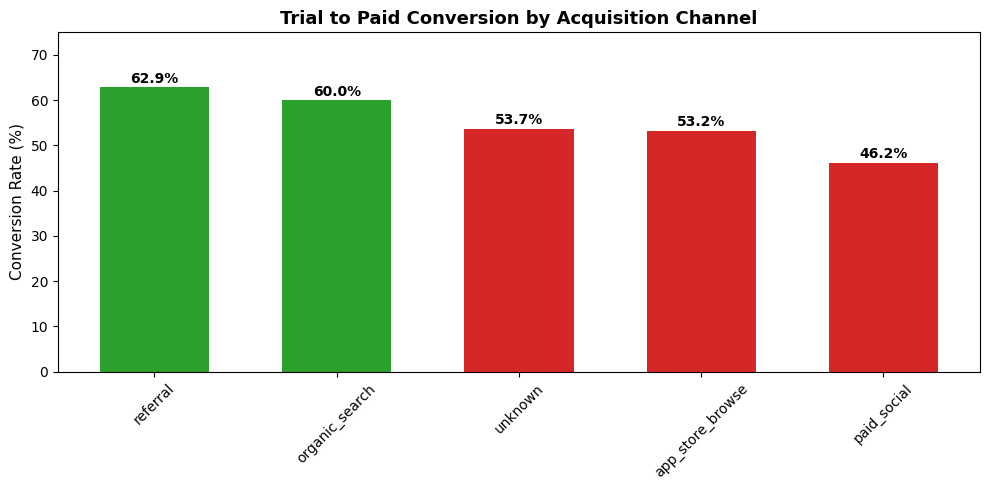

All 5 visualizations saved to figures/


In [6]:
# VIS 5: Conversion by Acquisition Channel
conversion = pd.read_sql("""
    SELECT acquisition_channel,
           ROUND(100.0 * SUM(converted_to_paid::INT) / COUNT(*), 2) AS conversion_rate
    FROM breathwork_app_schema.mart_user_activation
    GROUP BY acquisition_channel
    ORDER BY conversion_rate DESC
""", engine)
 
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2ca02c' if x > 55 else '#d62728' for x in conversion['conversion_rate']]
ax.bar(conversion['acquisition_channel'], conversion['conversion_rate'], color=colors, width=0.6)
ax.set_ylabel('Conversion Rate (%)', fontsize=11)
ax.set_ylim(0, 75)
for i, v in enumerate(conversion['conversion_rate']):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
plt.title('Trial to Paid Conversion by Acquisition Channel', fontsize=13, fontweight='bold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('figures/05_conversion_by_channel.png', dpi=300, bbox_inches='tight')
plt.show()
 
print("All 5 visualizations saved to figures/")